# 06 — Building-Level Pluvial Flood Susceptibility

This notebook combines terrain, hydrologic, and spatial rainfall attributes
to construct an interpretable building-level pluvial flood susceptibility
index for Manhattan.

## Model inputs

Four terrain and hydrologic indicators are used:

1. Ground elevation
2. Local terrain slope
3. Filled-depression depth
4. Nearby D8 flow accumulation

The spatially interpolated NOAA Atlas 14 rainfall estimate is applied as a
local rainfall modifier.

## Interpretation

The output is a relative susceptibility score used to compare Manhattan
buildings under a 100-year, 30-minute design-rainfall scenario.

The score is not:

- a probability that a building will flood;
- a prediction of floodwater depth;
- a replacement for hydraulic or sewer-network modeling;
- a property-level insurance loss estimate.

Buildings without complete terrain coverage are retained in the output but
excluded from risk scoring.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Input and output paths
# ------------------------------------------------------------

building_input_path = (
    PROCESSED_DIR
    / "manhattan_buildings_with_terrain_rainfall.gpkg"
)

risk_output_path = (
    PROCESSED_DIR
    / "manhattan_building_flood_susceptibility.gpkg"
)


if not building_input_path.exists():
    raise FileNotFoundError(
        f"Building input was not found: {building_input_path}"
    )


# ------------------------------------------------------------
# Load building dataset
# ------------------------------------------------------------

buildings = gpd.read_file(
    building_input_path,
    layer="buildings",
)


# ------------------------------------------------------------
# Required model fields
# ------------------------------------------------------------

required_fields = [
    "dem_elevation_m",
    "slope_degrees",
    "depression_depth_m",
    "log10_flow_accumulation_10m",
    "rain_100y30m_est_mm",
    "rain_log_mu",
    "rain_log_sigma",
    "terrain_model_eligible",
]

missing_fields = [
    field
    for field in required_fields
    if field not in buildings.columns
]

if missing_fields:
    raise ValueError(
        f"Missing required fields: {missing_fields}"
    )


# ------------------------------------------------------------
# Separate eligible and excluded buildings
# ------------------------------------------------------------

eligible_mask = (
    buildings["terrain_model_eligible"]
    .fillna(False)
    .astype(bool)
)

eligible_buildings = buildings.loc[
    eligible_mask
].copy()

excluded_buildings = buildings.loc[
    ~eligible_mask
].copy()


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(buildings) == 45_195
assert len(eligible_buildings) == 45_169
assert len(excluded_buildings) == 26
assert buildings.crs is not None
assert buildings.geometry.notna().all()

assert eligible_buildings[
    required_fields[:-1]
].notna().all().all()


print("Total buildings:", len(buildings))
print("Eligible buildings:", len(eligible_buildings))
print("Excluded buildings:", len(excluded_buildings))
print(
    "Scoring coverage:",
    f"{eligible_mask.mean():.2%}",
)
print("CRS:", buildings.crs)
print("Building-risk input validation: PASS")

Total buildings: 45195
Eligible buildings: 45169
Excluded buildings: 26
Scoring coverage: 99.94%
CRS: EPSG:6539
Building-risk input validation: PASS


## Terrain susceptibility components

The four terrain variables use different units and distributions. They are
therefore converted into empirical percentile-based susceptibility components
between 0 and 1.

The direction of risk is defined as follows:

| Component | Higher susceptibility condition |
|---|---|
| Elevation | Lower ground elevation |
| Flatness | Lower terrain slope |
| Depression | Greater filled-depression depth |
| Flow accumulation | Greater nearby flow accumulation |

For a variable where larger values imply greater susceptibility, the component
is calculated from its empirical rank:

$$
C_{bi} =
\frac{
r_{bi}-r_i^{\min}
}{
r_i^{\max}-r_i^{\min}
}
$$

For elevation and slope, where smaller values imply greater susceptibility,
the ranking direction is reversed:

$$
C_{bi}^{\mathrm{reversed}} = 1-C_{bi}
$$

These components are relative rankings within Manhattan. A value of 0.90 means
that the building has greater susceptibility on that indicator than most
eligible Manhattan buildings; it does not mean a 90% probability of flooding.

Low slope is treated as a ponding-susceptibility indicator. This is a
screening assumption: steep terrain can generate rapid runoff, while flat
terrain is generally less able to drain water locally.

In [2]:
# ------------------------------------------------------------
# Empirical susceptibility-score function
# ------------------------------------------------------------

def empirical_susceptibility_score(
    values,
    higher_values_mean_higher_risk=True,
):
    """
    Convert a numeric variable into a 0-to-1 empirical
    susceptibility score.

    Tied values receive their average rank.
    """

    numeric_values = pd.to_numeric(
        values,
        errors="coerce",
    )

    if numeric_values.isna().any():
        raise ValueError(
            f"Missing values found in {values.name}"
        )

    ranks = numeric_values.rank(
        method="average"
    )

    rank_range = (
        ranks.max()
        - ranks.min()
    )

    if rank_range == 0:
        raise ValueError(
            f"{values.name} has no variation."
        )

    normalized_rank = (
        ranks
        - ranks.min()
    ) / rank_range

    if higher_values_mean_higher_risk:
        score = normalized_rank
    else:
        score = 1.0 - normalized_rank

    return score.clip(
        lower=0.0,
        upper=1.0,
    )


# ------------------------------------------------------------
# Construct terrain susceptibility components
# ------------------------------------------------------------

eligible_buildings["component_low_elevation"] = (
    empirical_susceptibility_score(
        eligible_buildings["dem_elevation_m"],
        higher_values_mean_higher_risk=False,
    )
)

eligible_buildings["component_flatness"] = (
    empirical_susceptibility_score(
        eligible_buildings["slope_degrees"],
        higher_values_mean_higher_risk=False,
    )
)

eligible_buildings["component_depression"] = (
    empirical_susceptibility_score(
        eligible_buildings["depression_depth_m"],
        higher_values_mean_higher_risk=True,
    )
)

eligible_buildings["component_flow"] = (
    empirical_susceptibility_score(
        eligible_buildings[
            "log10_flow_accumulation_10m"
        ],
        higher_values_mean_higher_risk=True,
    )
)


component_fields = [
    "component_low_elevation",
    "component_flatness",
    "component_depression",
    "component_flow",
]


# ------------------------------------------------------------
# Validate component values
# ------------------------------------------------------------

assert eligible_buildings[
    component_fields
].notna().all().all()

assert (
    eligible_buildings[component_fields]
    .ge(0.0)
    .all()
    .all()
)

assert (
    eligible_buildings[component_fields]
    .le(1.0)
    .all()
    .all()
)


print("Terrain susceptibility components: PASS")

print("\nComponent summary:")

display(
    eligible_buildings[
        component_fields
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    ).round(3)
)


print("\nComponent correlation matrix:")

display(
    eligible_buildings[
        component_fields
    ].corr().round(3)
)

Terrain susceptibility components: PASS

Component summary:


,component_low_elevation,component_flatness,component_depression,component_flow
count,45169.000,45169.000,45169.000,45169.000
mean,0.500,0.500,0.283,0.500
std,0.289,0.289,0.365,0.289
min,0.000,0.000,0.000,0.000
1%,0.010,0.010,0.000,0.012
5%,0.050,0.050,0.000,0.054
25%,0.250,0.250,0.000,0.251
50%,0.500,0.500,0.000,0.501
75%,0.750,0.750,0.641,0.750
95%,0.950,0.950,0.928,0.950



Component correlation matrix:


,component_low_elevation,component_flatness,component_depression,component_flow
component_low_elevation,1.000,0.112,0.205,0.055
component_flatness,0.112,1.000,-0.259,-0.078
component_depression,0.205,-0.259,1.000,0.342
component_flow,0.055,-0.078,0.342,1.000


The rainfall-adjusted index is converted to a 0–100 screening score:

$$
S_b =
100 \times
\min\left(
\max(H_b,0),
1
\right)
$$

Fixed score thresholds are used to assign susceptibility classes:

| Score | Susceptibility class |
|---:|---|
| 0–20 | Very Low |
| 20–40 | Low |
| 40–60 | Moderate |
| 60–80 | High |
| 80–100 | Very High |

Unlike percentile-based quintiles, these thresholds do not force each class
to contain the same number of buildings. Class sizes are determined by the
distribution of the composite susceptibility index.

The score remains a relative screening index and should not be interpreted as
a calibrated flood probability.

In [4]:
# ------------------------------------------------------------
# Baseline component weights
# ------------------------------------------------------------

BASELINE_WEIGHTS = {
    "component_low_elevation": 0.25,
    "component_flatness": 0.25,
    "component_depression": 0.25,
    "component_flow": 0.25,
}

assert np.isclose(
    sum(BASELINE_WEIGHTS.values()),
    1.0,
)


# ------------------------------------------------------------
# Calculate terrain susceptibility index
# ------------------------------------------------------------

eligible_buildings["terrain_index_raw"] = 0.0

for component, weight in BASELINE_WEIGHTS.items():

    eligible_buildings["terrain_index_raw"] += (
        eligible_buildings[component]
        * weight
    )


# ------------------------------------------------------------
# Calculate local rainfall modifier
# ------------------------------------------------------------

median_rainfall_mm = eligible_buildings[
    "rain_100y30m_est_mm"
].median()

eligible_buildings["rainfall_modifier"] = (
    eligible_buildings["rain_100y30m_est_mm"]
    / median_rainfall_mm
)


# ------------------------------------------------------------
# Calculate rainfall-adjusted index
# ------------------------------------------------------------

eligible_buildings["hazard_index_raw"] = (
    eligible_buildings["terrain_index_raw"]
    * eligible_buildings["rainfall_modifier"]
)

# ------------------------------------------------------------
# Convert the adjusted index to a 0-to-100 screening score
# ------------------------------------------------------------

eligible_buildings["susceptibility_score"] = (
    100
    * eligible_buildings[
        "hazard_index_raw"
    ].clip(
        lower=0.0,
        upper=1.0,
    )
)


# ------------------------------------------------------------
# Assign fixed susceptibility classes
# ------------------------------------------------------------

risk_class_order = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High",
]

eligible_buildings["susceptibility_class"] = pd.cut(
    eligible_buildings["susceptibility_score"],
    bins=[
        -np.inf,
        20,
        40,
        60,
        80,
        np.inf,
    ],
    labels=risk_class_order,
    ordered=True,
)


# ------------------------------------------------------------
# Validate baseline scores
# ------------------------------------------------------------

assert eligible_buildings[
    [
        "terrain_index_raw",
        "rainfall_modifier",
        "hazard_index_raw",
        "susceptibility_score",
        "susceptibility_class",
    ]
].notna().all().all()

assert eligible_buildings[
    "susceptibility_score"
].between(
    0,
    100,
).all()


print("Baseline susceptibility model: PASS")

print(
    "\nMedian rainfall estimate:",
    round(median_rainfall_mm, 4),
    "mm",
)

print(
    "Rainfall modifier range:",
    round(
        eligible_buildings[
            "rainfall_modifier"
        ].min(),
        4,
    ),
    "to",
    round(
        eligible_buildings[
            "rainfall_modifier"
        ].max(),
        4,
    ),
)

print("\nSusceptibility-score summary:")

display(
    eligible_buildings[
        [
            "terrain_index_raw",
            "rainfall_modifier",
            "hazard_index_raw",
            "susceptibility_score",
        ]
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    ).round(4)
)

print("\nBuildings by susceptibility class:")

display(
    eligible_buildings[
        "susceptibility_class"
    ].value_counts(
        sort=False
    )
)

Baseline susceptibility model: PASS

Median rainfall estimate: 57.5982 mm
Rainfall modifier range: 0.9772 to 1.0037

Susceptibility-score summary:


,terrain_index_raw,rainfall_modifier,hazard_index_raw,susceptibility_score
count,45169.0000,45169.0000,45169.0000,45169.0000
mean,0.4456,0.9979,0.4448,44.4760
std,0.1694,0.0052,0.1692,16.9210
min,0.0071,0.9772,0.0070,0.6997
1%,0.1001,0.9774,0.0990,9.8979
5%,0.1758,0.9857,0.1749,17.4947
25%,0.3192,0.9952,0.3187,31.8686
50%,0.4418,1.0000,0.4413,44.1256
75%,0.5662,1.0008,0.5656,56.5560
95%,0.7305,1.0028,0.7297,72.9745



Buildings by susceptibility class:


susceptibility_class
Very Low      3313
Low          15346
Moderate     17718
High          8042
Very High      750
Name: count, dtype: int64

## Monte Carlo propagation to building scores

The 10,000 correlated NOAA rainfall scenarios are propagated through the
building susceptibility model while holding the baseline terrain weights
constant.

For building \(b\) and simulation \(s\):

$$
R_{b,s} =
\exp\left(
\mu_b + \sigma_b Z_s
\right)
$$

The simulated susceptibility score is:

$$
S_{b,s} =
100 \times
\min\left[
T_b
\left(
\frac{R_{b,s}}{\widetilde{P}}
\right),
1
\right]
$$

where:

- \(T_b\) is the building's terrain susceptibility index;
- \(R_{b,s}\) is its simulated rainfall depth;
- \(\widetilde{P}\) is the median baseline rainfall depth;
- \(Z_s\) is shared by every Manhattan building in simulation \(s\).

The model calculates:

- mean simulated score;
- score standard deviation;
- 5th, 50th, and 95th percentile scores;
- frequency with which the score exceeds the High threshold;
- frequency with which the score exceeds the Very High threshold.

These frequencies describe classification sensitivity to NOAA rainfall
parameter uncertainty. They are not probabilities that a building will flood.

In [5]:
from time import perf_counter


# ------------------------------------------------------------
# Load previously generated rainfall scenarios
# ------------------------------------------------------------

rainfall_scenario_path = (
    PROCESSED_DIR
    / "noaa_atlas14_100yr_30min_rainfall_scenarios.csv"
)

if not rainfall_scenario_path.exists():
    raise FileNotFoundError(
        f"Rainfall scenario file not found: "
        f"{rainfall_scenario_path}"
    )

rainfall_scenario_table = pd.read_csv(
    rainfall_scenario_path
)

required_scenario_field = "shared_standard_normal"

if required_scenario_field not in rainfall_scenario_table.columns:
    raise ValueError(
        "The rainfall scenario table does not contain "
        "'shared_standard_normal'."
    )


shared_z = rainfall_scenario_table[
    required_scenario_field
].to_numpy(
    dtype=np.float32
)

N_SIMULATIONS = len(shared_z)

assert N_SIMULATIONS == 10_000


# ------------------------------------------------------------
# Prepare building-level arrays
# ------------------------------------------------------------

terrain_index = eligible_buildings[
    "terrain_index_raw"
].to_numpy(
    dtype=np.float32
)

building_log_mu = eligible_buildings[
    "rain_log_mu"
].to_numpy(
    dtype=np.float32
)

building_log_sigma = eligible_buildings[
    "rain_log_sigma"
].to_numpy(
    dtype=np.float32
)

median_rainfall_in = (
    median_rainfall_mm
    / 25.4
)

number_of_buildings = len(
    eligible_buildings
)


# ------------------------------------------------------------
# Accumulators for simulation statistics
# ------------------------------------------------------------

score_sum = np.zeros(
    number_of_buildings,
    dtype=np.float64,
)

score_squared_sum = np.zeros(
    number_of_buildings,
    dtype=np.float64,
)

high_or_above_count = np.zeros(
    number_of_buildings,
    dtype=np.int32,
)

very_high_count = np.zeros(
    number_of_buildings,
    dtype=np.int32,
)


# ------------------------------------------------------------
# Process simulations in batches to control memory use
# ------------------------------------------------------------

BATCH_SIZE = 100

simulation_start = perf_counter()

for batch_start in range(
    0,
    N_SIMULATIONS,
    BATCH_SIZE,
):

    batch_end = min(
        batch_start + BATCH_SIZE,
        N_SIMULATIONS,
    )

    z_batch = shared_z[
        batch_start:batch_end
    ]

    simulated_rainfall_in = np.exp(
        building_log_mu[:, np.newaxis]
        + building_log_sigma[:, np.newaxis]
        * z_batch[np.newaxis, :]
    )

    simulated_scores = (
        100.0
        * terrain_index[:, np.newaxis]
        * (
            simulated_rainfall_in
            / median_rainfall_in
        )
    )

    simulated_scores = np.clip(
        simulated_scores,
        0.0,
        100.0,
    )

    score_sum += simulated_scores.sum(
        axis=1,
        dtype=np.float64,
    )

    score_squared_sum += (
        simulated_scores**2
    ).sum(
        axis=1,
        dtype=np.float64,
    )

    high_or_above_count += (
        simulated_scores > 60
    ).sum(
        axis=1,
    )

    very_high_count += (
        simulated_scores > 80
    ).sum(
        axis=1,
    )


simulation_seconds = (
    perf_counter()
    - simulation_start
)


# ------------------------------------------------------------
# Calculate Monte Carlo summary statistics
# ------------------------------------------------------------

mc_score_mean = (
    score_sum
    / N_SIMULATIONS
)

mc_score_variance = (
    score_squared_sum
    / N_SIMULATIONS
    - mc_score_mean**2
)

mc_score_std = np.sqrt(
    np.maximum(
        mc_score_variance,
        0.0,
    )
)


# Quantiles can be calculated from the shared monotonic Z values

z_p05, z_p50, z_p95 = np.quantile(
    shared_z,
    [
        0.05,
        0.50,
        0.95,
    ],
)


def score_at_standard_normal(z_value):

    rainfall_in = np.exp(
        building_log_mu
        + building_log_sigma
        * z_value
    )

    score = (
        100.0
        * terrain_index
        * (
            rainfall_in
            / median_rainfall_in
        )
    )

    return np.clip(
        score,
        0.0,
        100.0,
    )


eligible_buildings["mc_score_mean"] = (
    mc_score_mean
)

eligible_buildings["mc_score_std"] = (
    mc_score_std
)

eligible_buildings["mc_score_p05"] = (
    score_at_standard_normal(z_p05)
)

eligible_buildings["mc_score_p50"] = (
    score_at_standard_normal(z_p50)
)

eligible_buildings["mc_score_p95"] = (
    score_at_standard_normal(z_p95)
)

eligible_buildings["mc_frequency_high_or_above"] = (
    high_or_above_count
    / N_SIMULATIONS
)

eligible_buildings["mc_frequency_very_high"] = (
    very_high_count
    / N_SIMULATIONS
)


# ------------------------------------------------------------
# Validate Monte Carlo results
# ------------------------------------------------------------

mc_output_fields = [
    "mc_score_mean",
    "mc_score_std",
    "mc_score_p05",
    "mc_score_p50",
    "mc_score_p95",
    "mc_frequency_high_or_above",
    "mc_frequency_very_high",
]

assert eligible_buildings[
    mc_output_fields
].notna().all().all()

assert (
    eligible_buildings["mc_score_p05"]
    <= eligible_buildings["mc_score_p50"]
).all()

assert (
    eligible_buildings["mc_score_p50"]
    <= eligible_buildings["mc_score_p95"]
).all()

assert eligible_buildings[
    "mc_frequency_high_or_above"
].between(
    0,
    1,
).all()

assert eligible_buildings[
    "mc_frequency_very_high"
].between(
    0,
    1,
).all()


print(
    "Monte Carlo calculation time:",
    round(simulation_seconds, 2),
    "seconds",
)

print(
    "Simulations:",
    N_SIMULATIONS,
)

print(
    "Eligible buildings:",
    number_of_buildings,
)

print("Monte Carlo building analysis: PASS")

display(
    eligible_buildings[
        mc_output_fields
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    ).round(4)
)

Monte Carlo calculation time: 5.75 seconds
Simulations: 10000
Eligible buildings: 45169
Monte Carlo building analysis: PASS


,mc_score_mean,mc_score_std,mc_score_p05,mc_score_p50,mc_score_p95,mc_frequency_high_or_above,mc_frequency_very_high
count,45169.0000,45169.0000,45169.0000,45169.0000,45169.0000,45169.0000,45169.0000
mean,45.2036,9.0835,31.7055,44.3578,61.4799,0.2175,0.0545
std,17.0289,3.1817,12.0494,16.8759,22.5943,0.2823,0.1165
min,0.7138,0.1519,0.4931,0.6978,0.9863,0.0000,0.0000
1%,10.0951,2.1054,6.9967,9.8710,13.8893,0.0000,0.0000
5%,17.8168,3.6694,12.4459,17.4479,24.4064,0.0000,0.0000
25%,32.4542,6.6533,22.7463,31.7855,44.3561,0.0010,0.0000
50%,44.9514,9.2304,31.4643,44.0094,61.4524,0.0636,0.0019
75%,57.5987,11.7631,40.3198,56.4088,78.8227,0.3804,0.0439
95%,73.7731,13.8037,51.9320,72.7800,100.0000,0.8258,0.3201


## Final building-level susceptibility outputs

The final output combines the deterministic baseline classification with
Monte Carlo sensitivity metrics.

The portfolio figure contains:

1. baseline building susceptibility classes;
2. the frequency with which each building's simulated score exceeds 60;
3. the number and percentage of buildings in each baseline class.

The Monte Carlo frequency represents classification sensitivity under NOAA
rainfall-estimate uncertainty. It must not be interpreted as a probability of
physical flooding.

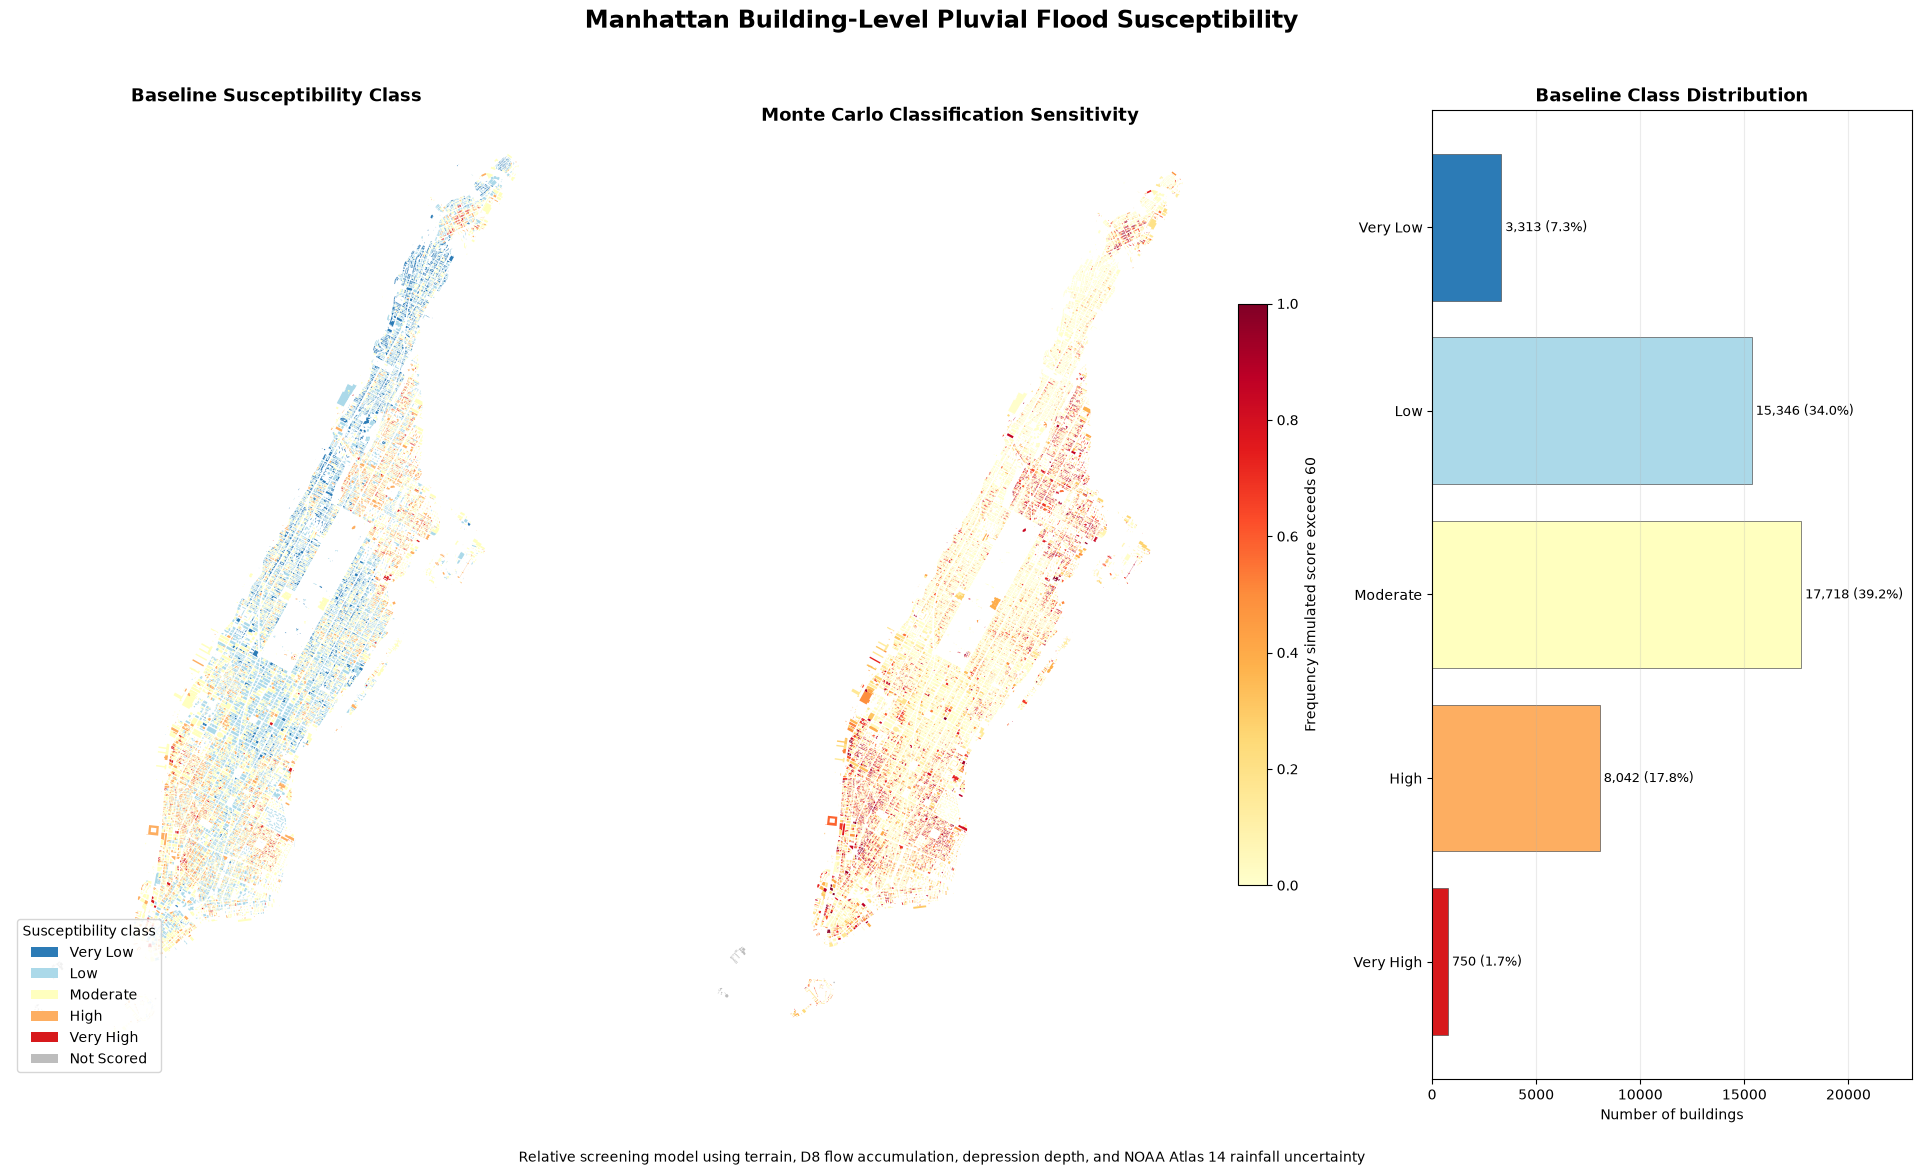

Saved final building dataset to:
C:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\data\processed\manhattan_building_flood_susceptibility.gpkg

Saved final portfolio figure to:
C:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\outputs\manhattan_building_flood_susceptibility.png

Final GeoPackage size: 36.65 MB

Final output validation: PASS


In [6]:
from matplotlib.patches import Patch


# ------------------------------------------------------------
# Model-output fields
# ------------------------------------------------------------

numeric_model_fields = [
    "component_low_elevation",
    "component_flatness",
    "component_depression",
    "component_flow",
    "terrain_index_raw",
    "rainfall_modifier",
    "hazard_index_raw",
    "susceptibility_score",
    "mc_score_mean",
    "mc_score_std",
    "mc_score_p05",
    "mc_score_p50",
    "mc_score_p95",
    "mc_frequency_high_or_above",
    "mc_frequency_very_high",
]


# ------------------------------------------------------------
# Merge eligible model results back into all buildings
# ------------------------------------------------------------

final_buildings = buildings.copy()

for field in numeric_model_fields:

    final_buildings[field] = np.nan

    final_buildings.loc[
        eligible_buildings.index,
        field,
    ] = eligible_buildings[field].to_numpy()


final_buildings["susceptibility_class"] = (
    "Not Scored"
)

final_buildings.loc[
    eligible_buildings.index,
    "susceptibility_class",
] = (
    eligible_buildings[
        "susceptibility_class"
    ]
    .astype(str)
    .to_numpy()
)


# ------------------------------------------------------------
# Validate merged dataset
# ------------------------------------------------------------

assert len(final_buildings) == 45_195

assert (
    final_buildings[
        "susceptibility_score"
    ].notna().sum()
    == 45_169
)

assert (
    final_buildings[
        "susceptibility_class"
    ].eq("Not Scored").sum()
    == 26
)


# ------------------------------------------------------------
# Save final GeoPackage
# ------------------------------------------------------------

final_buildings.to_file(
    risk_output_path,
    layer="buildings",
    driver="GPKG",
)


# ------------------------------------------------------------
# Class colors
# ------------------------------------------------------------

class_colors = {
    "Very Low": "#2c7bb6",
    "Low": "#abd9e9",
    "Moderate": "#ffffbf",
    "High": "#fdae61",
    "Very High": "#d7191c",
    "Not Scored": "#bdbdbd",
}


# ------------------------------------------------------------
# Create final portfolio figure
# ------------------------------------------------------------

final_figure_path = (
    OUTPUT_DIR
    / "manhattan_building_flood_susceptibility.png"
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 12),
    gridspec_kw={
        "width_ratios": [
            1.0,
            1.0,
            0.75,
        ]
    },
)


# ------------------------------------------------------------
# Panel 1: baseline susceptibility classes
# ------------------------------------------------------------

for risk_class in (
    risk_class_order
    + ["Not Scored"]
):

    class_subset = final_buildings.loc[
        final_buildings[
            "susceptibility_class"
        ].eq(risk_class)
    ]

    if len(class_subset) == 0:
        continue

    class_subset.plot(
        ax=axes[0],
        color=class_colors[risk_class],
        linewidth=0,
    )


legend_handles = [
    Patch(
        facecolor=class_colors[risk_class],
        edgecolor="none",
        label=risk_class,
    )
    for risk_class in (
        risk_class_order
        + ["Not Scored"]
    )
]

axes[0].legend(
    handles=legend_handles,
    title="Susceptibility class",
    loc="lower left",
    frameon=True,
)

axes[0].set_title(
    "Baseline Susceptibility Class",
    fontsize=13,
    fontweight="bold",
)

axes[0].set_axis_off()


# ------------------------------------------------------------
# Panel 2: Monte Carlo High-or-above frequency
# ------------------------------------------------------------

final_buildings.plot(
    ax=axes[1],
    column="mc_frequency_high_or_above",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidth=0,
    legend=True,
    legend_kwds={
        "label": (
            "Frequency simulated score exceeds 60"
        ),
        "shrink": 0.60,
    },
    missing_kwds={
        "color": "#bdbdbd",
        "label": "Not scored",
    },
)

axes[1].set_title(
    "Monte Carlo Classification Sensitivity",
    fontsize=13,
    fontweight="bold",
)

axes[1].set_axis_off()


# ------------------------------------------------------------
# Panel 3: class distribution
# ------------------------------------------------------------

class_counts = (
    eligible_buildings[
        "susceptibility_class"
    ]
    .value_counts(sort=False)
    .reindex(risk_class_order)
)

class_percentages = (
    100
    * class_counts
    / len(eligible_buildings)
)

bars = axes[2].barh(
    risk_class_order,
    class_counts,
    color=[
        class_colors[risk_class]
        for risk_class in risk_class_order
    ],
    edgecolor="#555555",
    linewidth=0.5,
)

axes[2].invert_yaxis()

axes[2].set_title(
    "Baseline Class Distribution",
    fontsize=13,
    fontweight="bold",
)

axes[2].set_xlabel(
    "Number of buildings"
)

axes[2].grid(
    axis="x",
    alpha=0.25,
)


for bar, count, percentage in zip(
    bars,
    class_counts,
    class_percentages,
):

    axes[2].text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({percentage:.1f}%)",
        va="center",
        fontsize=9,
    )


axes[2].set_xlim(
    0,
    class_counts.max() * 1.30,
)


# ------------------------------------------------------------
# Final figure formatting
# ------------------------------------------------------------

fig.suptitle(
    "Manhattan Building-Level Pluvial Flood Susceptibility",
    fontsize=17,
    fontweight="bold",
)

fig.text(
    0.5,
    0.02,
    (
        "Relative screening model using terrain, D8 flow accumulation, "
        "depression depth, and NOAA Atlas 14 rainfall uncertainty"
    ),
    ha="center",
    fontsize=10,
)

fig.tight_layout(
    rect=[
        0,
        0.04,
        1,
        0.96,
    ]
)

fig.savefig(
    final_figure_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Confirm final outputs
# ------------------------------------------------------------

assert risk_output_path.exists()
assert final_figure_path.exists()

print("Saved final building dataset to:")
print(risk_output_path)

print("\nSaved final portfolio figure to:")
print(final_figure_path)

print(
    "\nFinal GeoPackage size:",
    round(
        risk_output_path.stat().st_size
        / 1024**2,
        2,
    ),
    "MB",
)

print("\nFinal output validation: PASS")

## Final Results

The final dataset provides building-level pluvial-flood susceptibility results for Manhattan under a 100-year, 30-minute NOAA Atlas 14 rainfall scenario.

Of the 45,195 building footprints included in the study, 45,169 buildings (99.94%) had complete terrain and hydrologic information and were assigned a susceptibility score. The remaining 26 buildings were retained in the final dataset but classified as `Not Scored`.

### Baseline susceptibility distribution

- **Very Low:** 3,313 buildings (7.3%)
- **Low:** 15,346 buildings (34.0%)
- **Moderate:** 17,718 buildings (39.2%)
- **High:** 8,042 buildings (17.8%)
- **Very High:** 750 buildings (1.7%)

The baseline score combines four equally weighted terrain and hydrologic components:

1. low elevation;
2. terrain flatness;
3. filled-depression depth;
4. nearby D8 flow accumulation.

The composite terrain score is adjusted using the spatially interpolated NOAA Atlas 14 rainfall estimate.

### Rainfall uncertainty

Rainfall uncertainty was propagated through 10,000 spatially correlated Monte Carlo scenarios. For each building, the model records the mean, standard deviation, 5th, 50th, and 95th percentiles of the simulated susceptibility score.

The middle map shows the proportion of simulations in which each building's score exceeded 60, corresponding to the baseline `High` susceptibility threshold. It therefore indicates the stability of the screening classification under rainfall-estimate uncertainty.

> This frequency is not the probability that a building will flood. The model is a relative screening model and does not simulate drainage-system capacity, surface runoff depth, building entry elevations, or observed flood damage.